# Skincare Quality Control: Non-Normal pH Capability and OOS Risk Simulation

pH is a critical quality parameter in skincare products, as it is directly related to skin safety, formulation stability, and regulatory compliance.

In Quality Control (QC) practice, findings of pH values outside the specified limits (Out of Specification / OOS) represent a major issue that can halt production processes and trigger a comprehensive investigation.

Out of Specification (OOS) is defined as a pH value that falls outside the approved specification limits, namely below the Lower Specification Limit (LSL) or above the Upper Specification Limit (USL).

This notebook simulates how Statistical Process Control (SPC) is used to understand process conditions leading up to an OOS event. The analysis is limited to sunscreen batch pH data collected up to the date of the OOS occurrence.

This notebook is intended for educational simulation purposes and does not represent an official investigation report.

The objectives of this analysis are:
1. To identify the pH process conditions prior to the OOS event.
2. To evaluate process capability against the established specifications.
3. statistically estimate the risk of OOS occurrence.
4. To simulate the analytical steps typically performed when an OOS is identified.


## 1. Create and Exploratory Data Analysis (EDA)

In [1]:
!pip install scikit-posthocs

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, anderson, shapiro
import scipy.stats as stats
import numpy as np
from scipy.stats import spearmanr
import scikit_posthocs as sp
from scipy.stats import kruskal


In [3]:
data = pd.read_excel("/kaggle/input/skincare-quality/skincare_mixing_dummy.xlsx")

# Filter sunscreen
data_sunscreen = data[data["product_type"] == "sunscreen"].copy()

# Limitasi data sunscreen saat terjadinya OOS pada pH
data_sunscreen["month"] = data_sunscreen["process_date"].dt.to_period("M")

tanggal_oos_ph = "2024-06-05"
data_oos_ph_sunscreen = data_sunscreen[data_sunscreen["process_date"] <= tanggal_oos_ph].copy()
data_oos_ph_sunscreen["month"] = data_oos_ph_sunscreen["process_date"].dt.to_period("M")
data_oos_ph_sunscreen = data_oos_ph_sunscreen.sort_values(by=["month", "no_batch"]).reset_index(drop=True)
data_oos_ph_sunscreen["batch_seq"] = range(1, len(data_oos_ph_sunscreen) + 1)
data_oos_ph_sunscreen.head()

,process_date,release_mix_date,shift,line,operator_id,brand,product_type,name_product,batch_size,batch_code,...,pH_min,pH_max,pH,viscosity,product_weight,status_QC,inspector_id,failure_reason,month,batch_seq
0,2024-01-01,2024-01-01,Shift 1,1,operator_1,Brownies,sunscreen,Sunscreen SPF50,20,BR-SUN-0124-01,...,5.0,6.0,5.29,1746.0,19.38,PASS,inspector_1,NaN,2024-01,1
1,2024-01-01,2024-01-01,Shift 1,1,operator_1,Brownies,sunscreen,Sunscreen SPF50,20,BR-SUN-0124-02,...,5.0,6.0,5.23,2668.0,19.54,PASS,inspector_1,NaN,2024-01,2
2,2024-01-01,2024-01-01,Shift 2,1,operator_4,Brownies,sunscreen,Sunscreen SPF50,20,BR-SUN-0124-03,...,5.0,6.0,5.02,2426.0,19.35,PASS,inspector_2,NaN,2024-01,3
3,2024-01-01,2024-01-01,Shift 2,1,operator_4,Brownies,sunscreen,Sunscreen SPF50,20,BR-SUN-0124-04,...,5.0,6.0,5.12,2570.0,19.24,PASS,inspector_2,NaN,2024-01,4
4,2024-01-02,2024-01-02,Shift 1,1,operator_2,Brownies,sunscreen,Sunscreen SPF50,20,BR-SUN-0124-05,...,5.0,6.0,5.06,2886.0,19.52,PASS,inspector_1,NaN,2024-01,5


In [4]:
data_oos_ph_sunscreen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   process_date      452 non-null    datetime64[ns]
 1   release_mix_date  452 non-null    datetime64[ns]
 2   shift             452 non-null    object        
 3   line              452 non-null    int64         
 4   operator_id       452 non-null    object        
 5   brand             452 non-null    object        
 6   product_type      452 non-null    object        
 7   name_product      452 non-null    object        
 8   batch_size        452 non-null    int64         
 9   batch_code        452 non-null    object        
 10  no_batch          452 non-null    int64         
 11  pH_water          452 non-null    float64       
 12  pH_min            452 non-null    float64       
 13  pH_max            452 non-null    float64       
 14  pH                452 non-

In [5]:
data_oos_ph_sunscreen.describe()

,process_date,release_mix_date,line,batch_size,no_batch,pH_water,pH_min,pH_max,pH,viscosity,product_weight,batch_seq
count,452,452,452.0,452.0,452.000000,452.000000,452.0,452.0,452.000000,452.000000,452.000000,452.000000
mean,2024-03-18 14:39:17.522123776,2024-03-18 14:42:28.672566528,1.0,20.0,43.561947,6.525221,5.0,6.0,5.136969,2530.362832,19.401150,226.500000
min,2024-01-01 00:00:00,2024-01-01 00:00:00,1.0,20.0,1.000000,6.060000,5.0,6.0,4.980000,1505.000000,19.200000,1.000000
25%,2024-02-08 00:00:00,2024-02-08 00:00:00,1.0,20.0,21.000000,6.280000,5.0,6.0,5.050000,2086.500000,19.300000,113.750000
50%,2024-03-19 00:00:00,2024-03-19 00:00:00,1.0,20.0,43.000000,6.530000,5.0,6.0,5.120000,2523.000000,19.400000,226.500000
75%,2024-04-26 00:00:00,2024-04-26 00:00:00,1.0,20.0,66.000000,6.780000,5.0,6.0,5.220000,3027.000000,19.490000,339.250000
max,2024-06-05 00:00:00,2024-06-06 00:00:00,1.0,20.0,92.000000,7.010000,5.0,6.0,5.360000,3499.000000,19.600000,452.000000
std,NaN,NaN,0.0,0.0,25.954047,0.269664,0.0,0.0,0.091542,574.187772,0.115699,130.625419


## 2. I–MR Chart

To identify the pH process conditions prior to the occurrence of an Out of Specification (OOS) incident, the primary Statistical Process Control (SPC) tool used is the Individual–Moving Range (I–MR) chart.


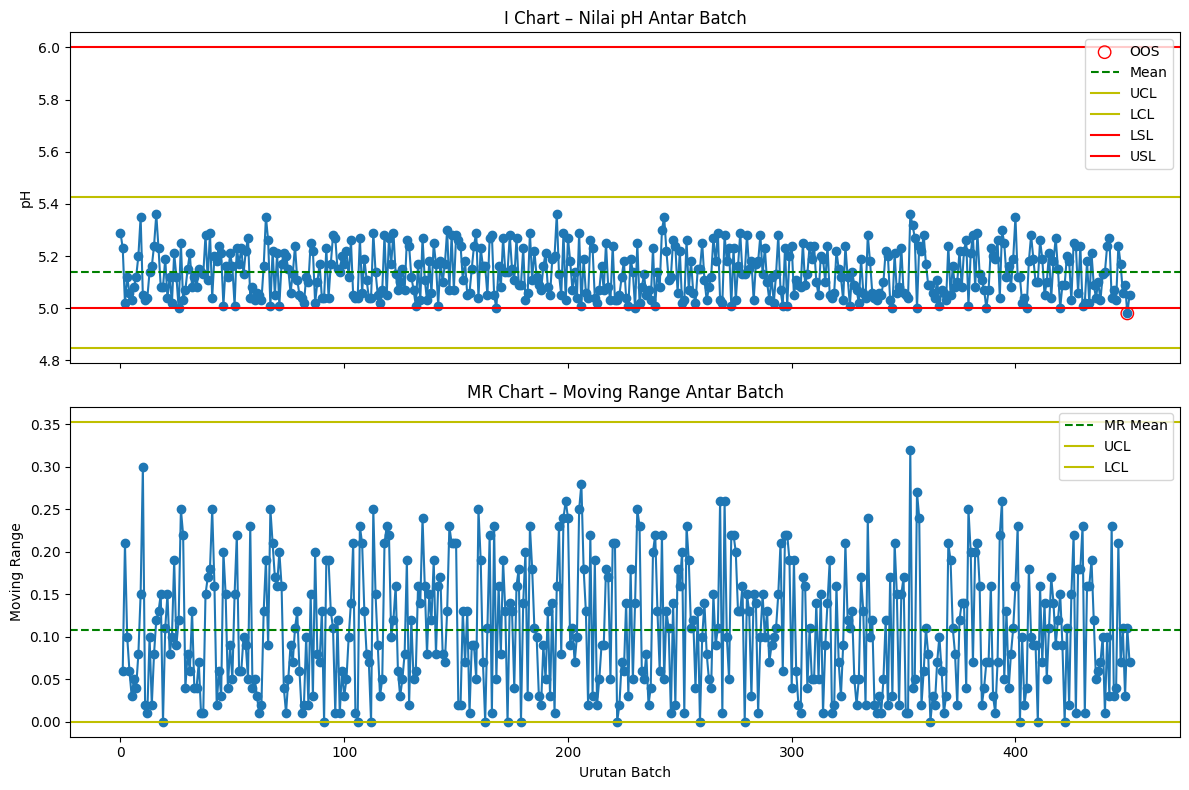

In [6]:
# 1. Ambil data pH
ph = data_oos_ph_sunscreen["pH"].reset_index(drop=True)

ph_min = data_oos_ph_sunscreen["pH_min"].iloc[0]
ph_max = data_oos_ph_sunscreen["pH_max"].iloc[0]

LSL = ph_min
USL = ph_max

# 2. Hitung Moving Range (MR)
MR = ph.diff().abs().dropna()

# 3. Hitung parameter I-Chart
Xbar = ph.mean()
MRbar = MR.mean()

# Konstanta SPC untuk MR size = 2
d2 = 1.128
D3 = 0
D4 = 3.267

# Estimasi sigma proses
sigma = MRbar / d2

UCL_I = Xbar + 3 * sigma
LCL_I = Xbar - 3 * sigma

# 4. Hitung parameter MR-Chart
UCL_MR = D4 * MRbar
LCL_MR = D3 * MRbar  # = 0

# 5. Plot I–MR Chart
oos_mask = (ph < LSL) | (ph > USL)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ----- I Chart -----
ax1.plot(ph.index, ph.values, marker='o', linestyle='-')
ax1.scatter(ph.index[oos_mask], ph[oos_mask], marker='o', s=80, edgecolors='red', facecolors='none', label='OOS')
ax1.axhline(Xbar, linestyle='--', label='Mean', color='g')
ax1.axhline(UCL_I, linestyle='-', label='UCL', color='y')
ax1.axhline(LCL_I, linestyle='-', label='LCL', color='y')
ax1.axhline(LSL, linestyle='-', label='LSL', color='r')
ax1.axhline(USL, linestyle='-', label='USL', color='r')

ax1.set_title("I Chart – Nilai pH Antar Batch")
ax1.set_ylabel("pH")
ax1.legend()

# ----- MR Chart -----
ax2.plot(MR.index, MR.values, marker='o', linestyle='-')
ax2.axhline(MRbar, linestyle='--', label='MR Mean', color='g')
ax2.axhline(UCL_MR, linestyle='-', label='UCL', color='y')
ax2.axhline(LCL_MR, linestyle='-', label='LCL', color='y')

ax2.set_title("MR Chart – Moving Range Antar Batch")
ax2.set_xlabel("Urutan Batch")
ax2.set_ylabel("Moving Range")
ax2.legend()

plt.tight_layout()
plt.show()

Based on the I–MR chart, the manufacturing process shows a statistically stable condition, characterized by all data points remaining within the control limits and consistent batch-to-batch variation. However, one Out of Specification (OOS) event was observed, in which the pH value fell below the specification limit (LSL), despite still being within the statistical control limits (UCL and LCL). This indicates that the primary issue does not originate from excessive process variation, but rather from a shift in the process mean that is positioned too close to the lower specification limit.

1. “As-Is” Product Scenario (Without pH Adjustment)

For products evaluated without the addition of a pH-adjusting agent, the measured pH values are expected to reflect the stability of the raw materials and the basic mixing process.

Indication:
If the MR chart shows sharp and irregular fluctuations (high variability), this suggests potential abnormalities in the measurement system (pH electrode). Industrial or laboratory pH meters typically have a measurement error margin of approximately ±0.02.

QC Analysis:
An unstable or contaminated electrode often produces noisy readings, causing apparent spikes in batch-to-batch differences even when the actual chemical condition of the product is stable. Such issues should ideally be detected early during the pH measurement stage.

2. Scenario with pH Agent Addition

For processes involving the addition of pH-adjusting agents (such as citric acid or NaOH) to achieve the target specification.

Indication:
Some degree of variability in the MR chart is considered acceptable, as it reflects active process correction.

QC Analysis:
Spikes in the MR chart in this scenario are more strongly influenced by dosing precision, mixing time, and the homogeneity of the mixture.

## 3. pH Distribution

After evaluating process stability using the I–MR chart, the next step is to understand the distribution characteristics of pH values prior to the OOS event.

Distribution analysis is performed to evaluate:
1. the position of the data relative to the specification limits.
2. the shape of the data distribution.
3. the tendency of pH values to cluster around specific specification boundaries.

For this purpose, histograms and boxplots are used as visualization tools for the pH distribution.

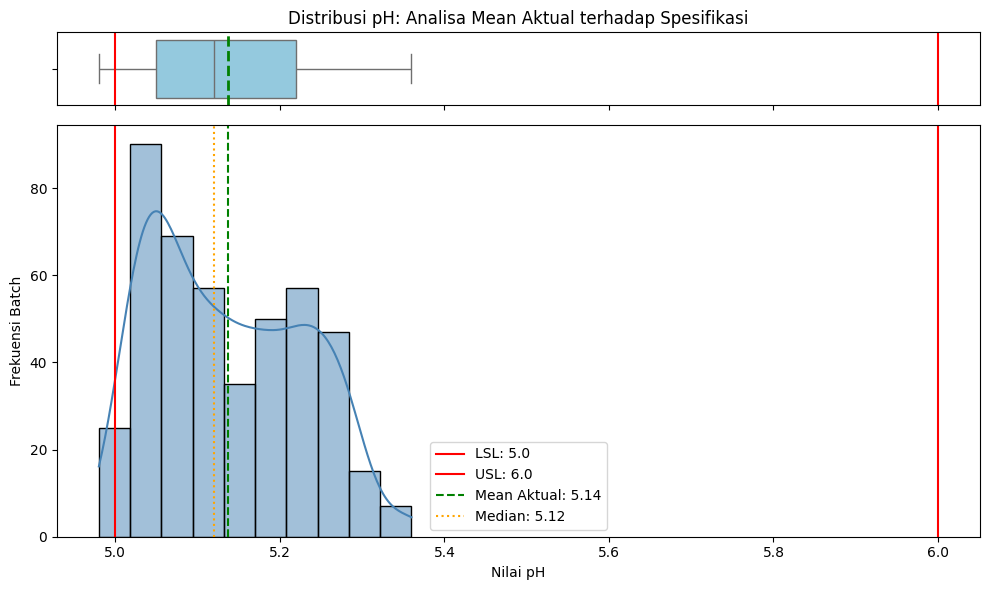

In [7]:
# 1. Hitung Statistik Deskriptif
ph_mean = data_oos_ph_sunscreen["pH"].mean() # Rata-rata aktual
ph_median = data_oos_ph_sunscreen["pH"].median()

# 2. Setup Figure
f, (ax_box, ax_hist) = plt.subplots(2, sharex=True, gridspec_kw={"height_ratios": (.15, .85)}, figsize=(10, 6))

# 3. Boxplot
sns.boxplot(x=data_oos_ph_sunscreen["pH"], ax=ax_box, color="skyblue")
ax_box.axvline(ph_min, color='red', linestyle='-', linewidth=1.5)
ax_box.axvline(ph_max, color='red', linestyle='-', linewidth=1.5)
ax_box.axvline(ph_mean, color='green', linestyle='--', linewidth=2)
ax_box.set(xlabel='')
ax_box.set_title("Distribusi pH: Analisa Mean Aktual terhadap Spesifikasi")

# 4. Histogram
sns.histplot(data_oos_ph_sunscreen["pH"], kde=True, ax=ax_hist, color="steelblue")
ax_hist.axvline(ph_min, color='red', linestyle='-', label=f'LSL: {ph_min}')
ax_hist.axvline(ph_max, color='red', linestyle='-', label=f'USL: {ph_max}')
ax_hist.axvline(ph_mean, color='green', linestyle='--', label=f'Mean Aktual: {ph_mean:.2f}')

# Median
ax_hist.axvline(ph_median, color='orange', linestyle=':', label=f'Median: {ph_median:.2f}')

ax_hist.legend()
plt.xlabel("Nilai pH")
plt.ylabel("Frekuensi Batch")
plt.tight_layout()
plt.show()

1. Boxplot (Upper Section)

Interquartile Range (Blue Box):
The blue box represents where 50% of the data lie. It can be observed that the box is positioned very close to the LSL line.

Whiskers (Horizontal Lines):
The lower whisker (left side) extends beyond the LSL line. This visually confirms that, statistically, the process has already produced OOS results during the data collection period.

2. Histogram (Lower Section)

The pH data distribution shows a positive skew, with the distribution tightly clustered toward the lower end.

LSL (Lower Specification Limit) at 5.0:
The left red specification line is positioned very close to the tail of the distribution.

High Risk:
Although the mean value is 5.14, there is a significant population of batches within the 5.0–5.1 range.

Conclusion:
The process lacks sufficient “buffer” or safety margin on the lower side. Even minor fluctuations in raw materials or small measurement errors from the pH electrode can immediately result in OOS products.

3. Mean vs. Median Analysis (Distribution Skewness)

Actual Mean (5.14) > Median (5.12).

This difference, combined with the histogram shape showing a higher concentration toward the lower pH region, indicates that the majority of products tend to have lower pH values.

Interpretation:
There is a systematic tendency in the production process that pulls pH values toward the lower specification limit (5.0).

## 3. Z-Score
Z-score analysis is used to understand the position of the process mean pH relative to the established specification limits. The Z-score represents the distance between the process mean and the specification limit in units of standard deviation (σ). This analysis helps identify the direction of risk (toward the LSL or USL) and provides an initial statistical estimation of Out of Specification (OOS) risk, without first assuming that the process is centered within the specification range.

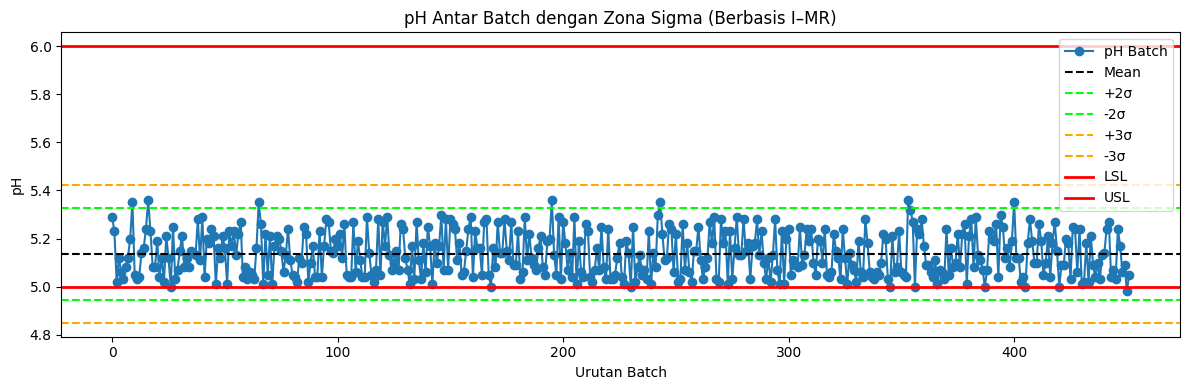

In [8]:
# Parameter proses
mu = ph_mean
sigma = sigma  # sigma dari I–MR

plt.figure(figsize=(12,4))
plt.plot(ph.index, ph.values, marker='o', linestyle='-', label='pH Batch')

# Mean
plt.axhline(mu, color='black', linestyle='--', label='Mean')

# Zona sigma
plt.axhline(mu + 2*sigma, color='lime', linestyle='--', label='+2σ')
plt.axhline(mu - 2*sigma, color='lime', linestyle='--', label='-2σ')

plt.axhline(mu + 3*sigma, color='orange', linestyle='--', label='+3σ')
plt.axhline(mu - 3*sigma, color='orange', linestyle='--', label='-3σ')

# Spesifikasi
plt.axhline(LSL, color='red', linestyle='-', linewidth=2, label='LSL')
plt.axhline(USL, color='red', linestyle='-', linewidth=2, label='USL')

plt.title("pH Antar Batch dengan Zona Sigma (Berbasis I–MR)")
plt.xlabel("Urutan Batch")
plt.ylabel("pH")
plt.legend()
plt.tight_layout()
plt.show()

The Z-score chart illustrates the deviation of each batch pH from the process mean in units of standard deviation (sigma), based on the I–MR analysis. Most values fall within the ±2σ range, and no points exceed ±3σ, indicating that the process is statistically stable. However, the Z-score distribution is skewed toward the negative side, which is consistent with the process mean being positioned close to the lower specification limit (LSL). As a result, the risk of OOS remains latent, even though the actual occurrence rate is relatively low.

| Z   | General Interpretation |
| --- | ---------------------- |
| 1.0 | Very high risk         |
| 2.0 | High risk              |
| 3.0 | Minimum acceptable     |
| 4.0 | Good (industry level)  |
| 6.0 | World class            |


## 4. Cp and Cpk
After evaluating process patterns and stability using the I–MR chart, as well as the pH distribution characteristics through histograms and boxplots, the next analysis focuses on evaluating process capability relative to the established specification limits.

The process capability indices Cp and Cpk are used to provide quantitative measures of the process’s ability to meet pH specifications.

Cp (Process Capability Index) represents the potential capability of a process by comparing the width of the specification limits to the natural variation of the process, assuming the process mean is perfectly centered between the specification limits.

Cpk (Process Capability Index, Centered) is an extension of Cp that takes into account the actual position of the process mean relative to the specification limits, thereby reflecting the actual performance of the process rather than its theoretical potential.

In [9]:
# mu = data_oos_ph_sunscreen["pH"].mean()
mu = ph_mean
sigma = sigma

# Hitung Cp & Cpk
Cp = (USL - LSL) / (6 * sigma)

Cpk_lower = (mu - LSL) / (3 * sigma)
Cpk_upper = (USL - mu) / (3 * sigma)
Cpk = min(Cpk_lower, Cpk_upper)

print(f"Cp  : {Cp:.2f}")
print(f"Cpk : {Cpk:.2f}")
print(f"Cpk (Lower) : {Cpk_lower:.2f}")
print(f"Cpk (Upper) : {Cpk_upper:.2f}")

Cp  : 1.74
Cpk : 0.48
Cpk (Lower) : 0.48
Cpk (Upper) : 3.00


Comparison of Potential vs. Actual Performance

Cp = 1.74 (Very Good / High Precision):
This value represents the potential capability of the process. Technically, the process variation is very small and tightly distributed. If the process mean were perfectly centered within the specification limits, this process would be considered highly stable and of high quality, as Cp > 1.33.

Cpk = 0.48 (Poor / Not Capable):
This value reflects the actual process performance. Because Cpk is significantly lower than Cp, it indicates that the process mean is not centered but instead is shifted close to one of the specification limits.

Upper and Lower Specification Analysis

Upper Cpk (3.00):
This value is extremely high, indicating that the process is very safe with respect to the upper specification limit (pH 6.0). There is virtually no risk of the product becoming overly alkaline.

Lower Cpk (0.48):
This is the critical point. Because the value is below 1.00 (and even below 0.50), the process has a high risk of producing Out of Specification (OOS) product below pH 5.0.

| Cpk Value   | General Interpretation                                               |
| ----------- | -------------------------------------------------------------------- |
| < 1.00      | Inadequate: The process is not capable of meeting specifications.    |
| 1.00 – 1.33 | Marginal: Meets specifications, but with a high risk of failure.     |
| ≥ 1.33      | Satisfactory / Good: Acceptable industry standard.                   |
| ≥ 1.67      | Excellent / World Class: Very low variation and high process safety. |

## 5. Comparison of OOS Risk: Statistical Estimation vs Actual Data

After analyzing the position of the pH process relative to the specification limits using Z-scores, the next step is to compare the theoretical Out of Specification (OOS) risk with the OOS events observed in the actual data. The theoretical OOS risk is calculated based on the assumption of a normal distribution using the process mean (μ) and process standard deviation (σ), which represent the probability of data falling outside the specification limits.

In contrast, the actual OOS rate is calculated directly from the proportion of batches with pH values below the lower specification limit (LSL) in the historical data.

This comparison aims to evaluate the validity of the statistical assumptions against real process behavior and to identify potential discrepancies between the theoretical model and the actual process conditions.


In [10]:
Z_LSL = (mu - LSL) / sigma
Z_USL = (USL - mu) / sigma

Z_min = min(Z_LSL, Z_USL)

P_OOS_LSL = norm.cdf(-Z_LSL)
P_OOS_USL = 1 - norm.cdf(Z_USL)

P_OOS_total = P_OOS_LSL + P_OOS_USL
P_OOS = norm.cdf(-Z_LSL)

print("=== Analisis Risiko OOS ===")
print(f"Mean proses        : {mu:.2f}")
print(f"Sigma proses       : {sigma:.3f}")
print(f"Z terhadap LSL     : {Z_LSL:.2f}")
print(f"Estimasi OOS (%)   : {P_OOS*100:.2f}%")

OOS_aktual = (ph < LSL).mean()

print(f"OOS aktual (%)     : {OOS_aktual*100:.2f}%")

Cpk = Z_min / 3
print(f"Cpk                : {Cpk:.2f}")


=== Analisis Risiko OOS ===
Mean proses        : 5.14
Sigma proses       : 0.096
Z terhadap LSL     : 1.43
Estimasi OOS (%)   : 7.66%
OOS aktual (%)     : 0.22%
Cpk                : 0.48


The analysis results show that the process mean pH is 5.14, with a process standard deviation of 0.096. The distance between the process mean and the lower specification limit (LSL) corresponds to 1.43 standard deviations (Z = 1.43).

Based on the assumption of a normal distribution, this condition theoretically indicates an OOS risk of 7.66%. However, the OOS frequency observed in the actual data is only 0.22%, which is significantly lower than the theoretical estimate.

The significant discrepancy between the theoretical OOS rate and the actual OOS rate suggests that the statistical assumptions used in the Z-score calculation may not fully represent the actual behavior of the process.

## 6. Normality Test

Normality test was performed to verify the distribution of pH data.

### a. Q-Q Plot
Normality testing was performed using both visual methods (Q–Q plots) and statistical tests (Shapiro–Wilk and Anderson–Darling). This approach was applied to ensure that the normality assumptions underlying the Z-score analysis and process capability evaluation are valid and justifiable.

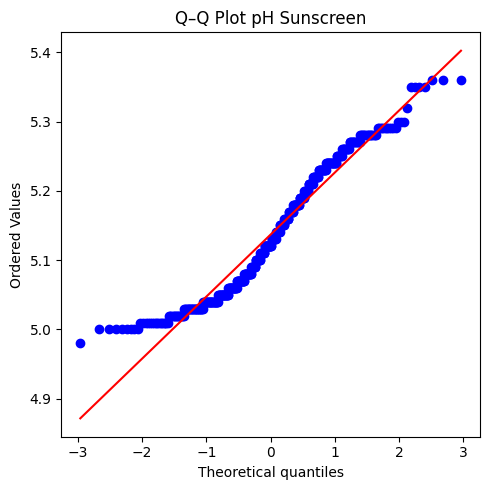

In [11]:
plt.figure(figsize=(5,5))
stats.probplot(data_oos_ph_sunscreen["pH"], dist="norm", plot=plt)
plt.title("Q–Q Plot pH Sunscreen")
plt.tight_layout()
plt.show()

The Q–Q plot shows that the pH distribution follows a normal pattern in the central portion of the distribution but exhibits significant deviation on the lower side (near the LSL). This indicates the presence of truncation or operational controls that limit pH values from falling below a certain threshold. Therefore, the assumption of full normality is not fully satisfied, and OOS risk estimates based on a normal distribution tend to be overestimated compared to the actual process conditions.

### b. Anderson-Darling


In [12]:
result = anderson(data_oos_ph_sunscreen["pH"], dist='norm')

print("A-D Statistic:", result.statistic)
for sl, cv in zip(result.significance_level, result.critical_values):
    print(f"{sl}%  critical value = {cv}")

A-D Statistic: 7.784007624041976
15.0%  critical value = 0.571
10.0%  critical value = 0.65
5.0%  critical value = 0.78
2.5%  critical value = 0.91
1.0%  critical value = 1.083


The Anderson–Darling test results show a test statistic of 7.78, which is far above all critical values at significance levels ranging from 1% to 15%. Therefore, the hypothesis that the pH data follow a normal distribution is rejected with high statistical significance. This finding indicates that the pH distribution is non-normal, likely due to operational constraints on the lower side of the distribution (near the LSL). As a result, analyses based on the normality assumption should be interpreted with caution.

### c. Shapiro-Wilk

In [13]:
stat, p = shapiro(data_oos_ph_sunscreen["pH"])
print("Shapiro p-value:", p)

Shapiro p-value: 1.0939852546515142e-11


The Shapiro–Wilk test yields a p-value of 1.09×10⁻¹¹, which is far below the 0.05 significance level; therefore, the hypothesis of normality is rejected. This result is consistent with the Anderson–Darling test and the Q–Q plot, indicating that the pH distribution is non-normal, likely due to operational constraints on the minimum pH values.

## 7. Percentile

Because the normality test results indicate that the pH data distribution does not follow a normal distribution, the conventional process capability approach using Cp and Cpk becomes less representative. Therefore, at this stage, a percentile-based process capability analysis is applied.

This approach evaluates process capability by comparing the actual percentiles of the data distribution against the specification limits, without assuming any specific distribution shape. This method is more suitable for non-normal final product quality data (final batch results) and is commonly used in risk-based assessments within Quality Control.

In [14]:
pH = ph

P00135 = np.percentile(pH, 0.135) # P0.135 ≈ batas 3σ bawah ekuivalen normal
P50 = np.percentile(pH, 50) # P50 = median
P99865 = np.percentile(pH, 99.865)

Cpl_p = (P50 - LSL) / (P50 - P00135)

print("=== Non-Normal Capability (Percentile-Based) ===")
print(f"P0.135  : {P00135:.3f}")
print(f"P50     : {P50:.3f}")
print(f"Cpl(p)  : {Cpl_p:.2f}")

=== Non-Normal Capability (Percentile-Based) ===
P0.135  : 4.992
P50     : 5.120
Cpl(p)  : 0.94


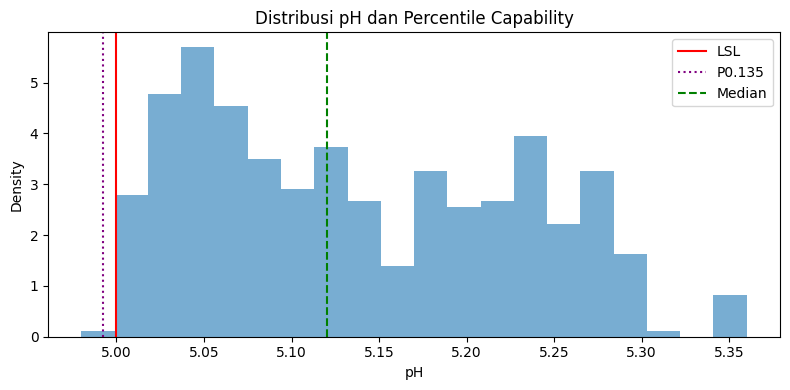

In [15]:
plt.figure(figsize=(8,4))
plt.hist(pH, bins=20, density=True, alpha=0.6)
plt.axvline(LSL, color='red', linestyle='-', label='LSL')
plt.axvline(P00135, color='purple', linestyle=':', label='P0.135')
plt.axvline(P50, color='green', linestyle='--', label='Median')

plt.legend()
plt.title("Distribusi pH dan Percentile Capability")
plt.xlabel("pH")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

The results of the percentile-based process capability analysis show the following characteristics of the pH distribution:

P0.135 = 4.992
This value represents the lower percentile (approximately the lower 3σ side) of the actual pH distribution. In practical terms, about 0.135% of the data are expected to be at or below a pH value of 4.992. This value lies very close to the lower specification limit (LSL = 5.0), indicating a potential risk of OOS on the lower specification side.

P50 = 5.120
The 50th percentile (median) represents the center of the pH process distribution. This value indicates that the process tends to operate slightly above the LSL but is not centered within the specification range (5.0–6.0), suggesting that the process is not optimally centered.

Cpl(p) = 0.94
The lower percentile-based capability index (Lower Percentile Capability) is less than 1.0, indicating that the process is not fully capable of consistently meeting the lower specification limit. From a practical standpoint, this suggests that a small portion of process variation still has the potential to produce batches with pH values below the LSL.

## 8. Mitigation

**a. pH distribution across shifts**

<Figure size 700x500 with 0 Axes>

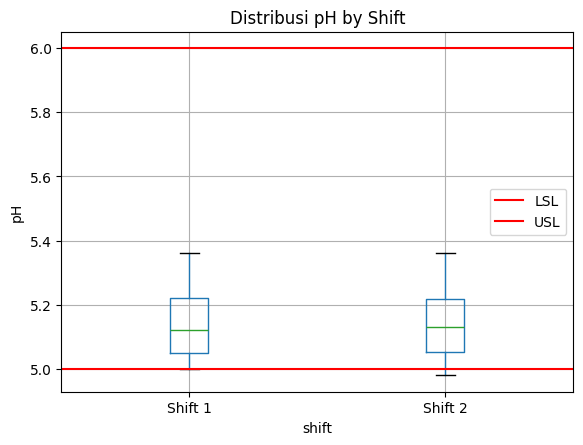

In [16]:
plt.figure(figsize=(7, 5))
data_oos_ph_sunscreen.boxplot(column="pH",by="shift")

plt.axhline(LSL, linestyle="-", label="LSL", color="red")
plt.axhline(USL, linestyle="-", label="USL", color="red")

plt.title("Distribusi pH by Shift")
plt.suptitle("")
plt.ylabel("pH")
plt.legend()
plt.grid(True)
plt.show()

Median (Green Line):
The median values for both shifts are very similar, ranging from approximately 5.12 to 5.15. This indicates that, on average, the pH output quality for Shift 1 and Shift 2 remains consistent.

Interquartile Range (Blue Box):
The box sizes for both shifts are nearly identical, indicating that data variability across the two shifts is very similar.

OOS Risk:
Shift 2 shows a higher risk of OOS, as there are data points that fall below the lower specification limit.

Action Required:
An evaluation should be conducted to determine whether environmental or operational factors during Shift 2 contribute to the pH dropping below the specification threshold.

**b. pH distribution across inspectors**

<Figure size 700x500 with 0 Axes>

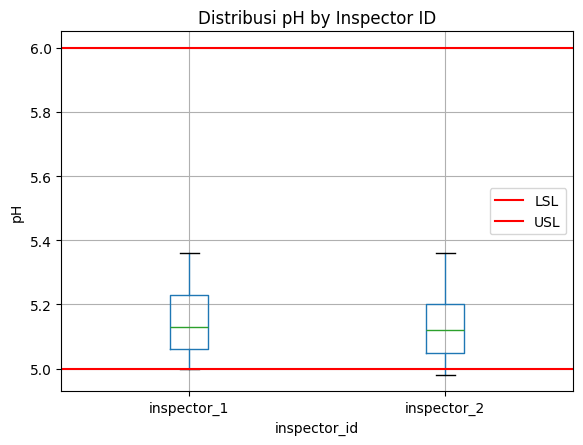

In [17]:
plt.figure(figsize=(7, 5))
data_oos_ph_sunscreen.boxplot(column="pH",by="inspector_id")

plt.axhline(LSL, linestyle="-", label="LSL", color="red")
plt.axhline(USL, linestyle="-", label="USL", color="red")

plt.title("Distribusi pH by Inspector ID")
plt.suptitle("")
plt.ylabel("pH")
plt.legend()
plt.grid(True)
plt.show()

Median (Green Line):
The median pH readings from inspector_1 and inspector_2 are nearly identical, ranging from approximately 5.12 to 5.15. This indicates that, on average, both inspectors produce consistent measurement results.

Variability (Box Range):
The blue boxes (Interquartile Range) for both inspectors are similar in size, indicating comparable levels of precision and data dispersion between them.

Upper Specification Limit (USL):
All data points are well below the upper limit of 6.0, indicating no issues related to excessively high pH values.

Lower Specification Limit (LSL):
A key finding is observed here. The lower tail (whisker) for inspector_2 extends below the red LSL line, indicating that several samples measured by inspector_2 fall below 5.0 (out of specification).

Inspector_1 appears to operate very close to the lower limit but, visually, remains at or slightly above the 5.0 threshold.

**c. pH distribution across operators**

<Figure size 700x500 with 0 Axes>

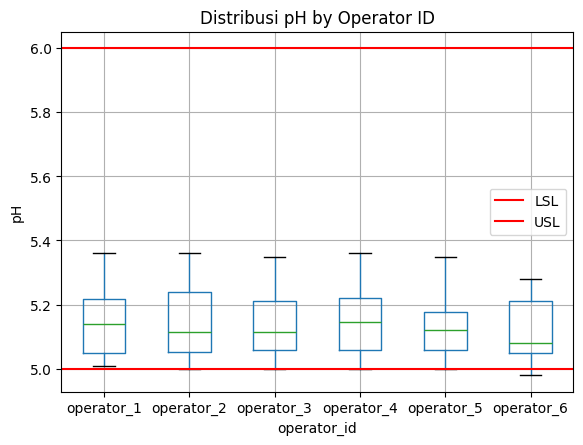

In [18]:
plt.figure(figsize=(7, 5))
data_oos_ph_sunscreen.boxplot(column="pH",by="operator_id")

plt.axhline(LSL, linestyle="-", label="LSL", color="red")
plt.axhline(USL, linestyle="-", label="USL", color="red")

plt.title("Distribusi pH by Operator ID")
plt.suptitle("")
plt.ylabel("pH")
plt.legend()
plt.grid(True)
plt.show()

The pH distribution across operators shows that all results remain within the specification limits. However, differences in median values and variability among operators indicate minor inconsistencies in process execution. Although these have not yet resulted in OOS events, such conditions may increase the risk of OOS when the process operates close to the lower specification limit (LSL).

Visually, the pH distribution for operator_6 tends to be closer to the lower specification limit (LSL), suggesting a potentially higher OOS risk compared to other operators. However, this finding is descriptive in nature and should be confirmed through non-parametric statistical testing to determine whether the observed differences are statistically significant.

In [19]:
# Kelompokkan pH berdasarkan operator
groups = [
    group["pH"].values
    for _, group in data_oos_ph_sunscreen.groupby("operator_id")]

# Kruskal–Wallis test
stat, p_value = kruskal(*groups)

print("=== Kruskal–Wallis Test ===")
print(f"H-statistic : {stat:.3f}")
print(f"p-value     : {p_value:.4f}")


=== Kruskal–Wallis Test ===
H-statistic : 4.143
p-value     : 0.5290


The Kruskal–Wallis test results show a p-value of 0.529 (> 0.05), indicating that there is no statistically significant difference in the pH distributions across operators. Therefore, the observed pH variation is systemic in nature and not attributable to any specific operator. Subsequent investigation should focus on process settings and the determination of the target pH.

In [20]:
dunn = sp.posthoc_dunn(data_oos_ph_sunscreen, val_col="pH", group_col="operator_id", p_adjust="bonferroni")
dunn

,operator_1,operator_2,operator_3,operator_4,operator_5,operator_6
operator_1,1.0,1.0,1.0,1.0,1.0,1.0
operator_2,1.0,1.0,1.0,1.0,1.0,1.0
operator_3,1.0,1.0,1.0,1.0,1.0,1.0
operator_4,1.0,1.0,1.0,1.0,1.0,1.0
operator_5,1.0,1.0,1.0,1.0,1.0,1.0
operator_6,1.0,1.0,1.0,1.0,1.0,1.0


**d. Correlation between pH and raw material**

Correlation analysis was conducted to assess the potential influence of raw material quality parameters on the final product pH, particularly with respect to possible changes in physicochemical properties that may affect pH stability.

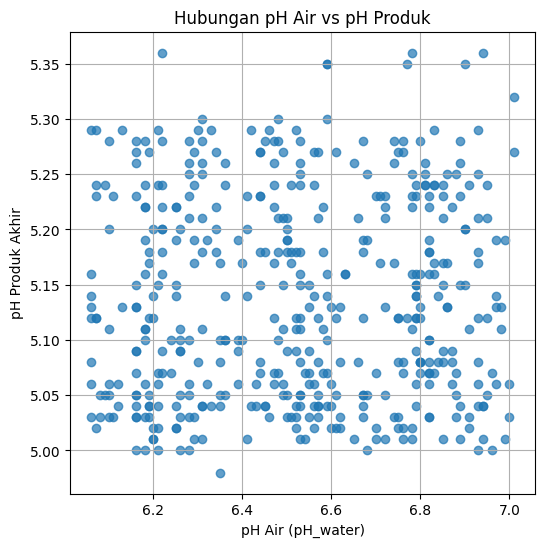

In [21]:
plt.figure(figsize=(6,6))
plt.scatter(data_oos_ph_sunscreen["pH_water"], data_oos_ph_sunscreen["pH"], alpha=0.7)
plt.xlabel("pH Air (pH_water)")
plt.ylabel("pH Produk Akhir")
plt.title("Hubungan pH Air vs pH Produk")
plt.grid(True)
plt.show()

In [22]:
rho, pval = spearmanr(data_oos_ph_sunscreen["pH_water"], data_oos_ph_sunscreen["pH"])

print(f"Spearman r : {rho:.3f}")
print(f"p-value    : {pval:.4f}")

Spearman r : 0.028
p-value    : 0.5493


Correlation analysis between water pH and final product pH was performed using the Spearman method because the pH data are not normally distributed. The results show a very weak correlation coefficient (r = 0.028) with a p-value greater than 0.05, indicating that there is no statistically significant relationship between variations in water pH and the final product pH.

Nevertheless, in a pH OOS investigation, the evaluation is not limited to process parameters alone but also includes the quality of raw materials tested by Raw Material QC. Therefore, further analysis is required to assess whether specific raw materials may potentially contribute to shifts in product pH, particularly materials that are acidic, alkaline, or possess buffering systems.

However, since this analysis is intended only as a simulation or illustrative example, only water pH was evaluated.

## 9. Conclusion & Decision Simulation

Based on the analyses performed, no significant relationship was found between water pH and final product pH, and no significant pH variation was observed across operators. Assuming that raw material quality meets specifications and remains within normal conditions, the primary source of pH OOS risk is more likely associated with a process that is not optimally centered relative to the lower specification limit (LSL).

Therefore, risk mitigation efforts should focus on re-adjusting the process pH target and re-evaluating the specification limits using a risk-based approach.

**a. Scheme 1 – pH Can Be Adjusted (Recommended as the First Step)**

In the first scenario, it is assumed that the product pH can be adjusted through a pH adjustment process. Under this condition, the product specifications are maintained, while the process pH target is gradually increased to center the data distribution within the specification range. Based on the simulation, a target pH in the range of 5.35–5.45 is recommended to improve process capability and reduce the risk of OOS.

In [23]:
mean_actual = pH.mean()
sigma_actual = pH.std(ddof=1)

LSL = 5.0
USL = 6.0

# Simulasi centering mean
mean_target = 5.37

pH_simulated = pH - mean_actual + mean_target

mean_sim = pH_simulated.mean()
sigma_sim = pH_simulated.std(ddof=1)

# Hitung Cp & Cpk simulasi
Cp_sim = (USL - LSL) / (6 * sigma_sim)

Cpk_lower_sim = (mean_sim - LSL) / (3 * sigma_sim)
Cpk_upper_sim = (USL - mean_sim) / (3 * sigma_sim)
Cpk_sim = min(Cpk_lower_sim, Cpk_upper_sim)

print("=== Simulasi Cp & Cpk ===")
print(f"Mean simulasi    : {mean_sim:.3f}")
print(f"Sigma simulasi   : {sigma_sim:.3f}")
print(f"Cp               : {Cp_sim:.2f}")
print(f"Cpk              : {Cpk_sim:.2f}")

=== Simulasi Cp & Cpk ===
Mean simulasi    : 5.370
Sigma simulasi   : 0.092
Cp               : 1.82
Cpk              : 1.35


Simulation of shifting the process mean to pH 5.37 shows a significant improvement in process capability, with Cp remaining high (1.82) and Cpk increasing to 1.35.

These results indicate that the process does not suffer from excessive variability but rather requires optimization of the process mean position relative to the specification limits. Setting the target process mean pH at 5.37 is considered adequate to reduce the risk of OOS and to meet recommended industry standards for process capability.

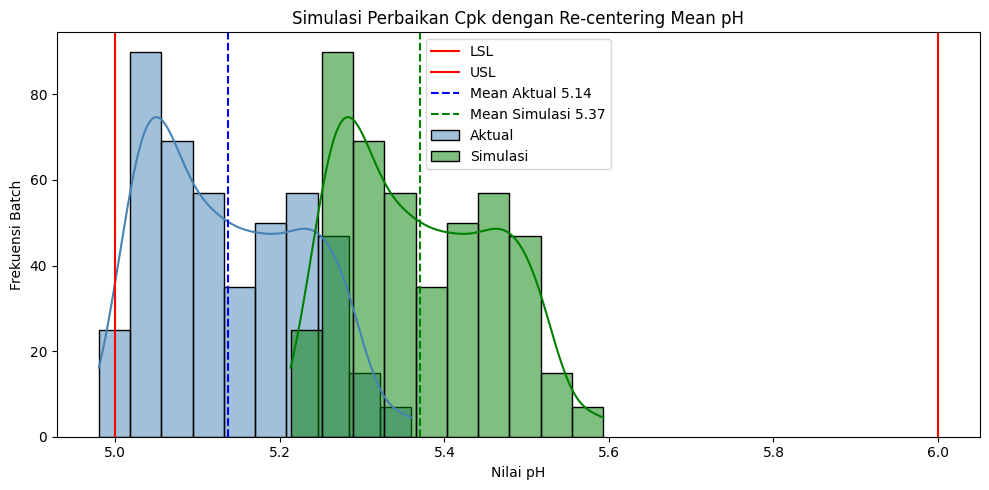

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(pH, color="steelblue", label="Aktual", kde=True, alpha=0.5)
sns.histplot(pH_simulated, color="green", label="Simulasi", kde=True, alpha=0.5)

plt.axvline(LSL, color="red", linestyle="-", label="LSL")
plt.axvline(USL, color="red", linestyle="-", label="USL")

plt.axvline(mean_actual, color="blue", linestyle="--", label=f"Mean Aktual {mean_actual:.2f}")
plt.axvline(mean_sim, color="green", linestyle="--", label=f"Mean Simulasi {mean_sim:.2f}")

plt.title("Simulasi Perbaikan Cpk dengan Re-centering Mean pH")
plt.xlabel("Nilai pH")
plt.ylabel("Frekuensi Batch")
plt.legend()
plt.tight_layout()
plt.show()

**b. Scheme 2 – Release by Acceptance (RBA)**

Based on a Risk-Based Acceptance approach, the sunscreen pH process is considered operationally acceptable. Although the Cpk value indicates statistical limitations, the low actual OOS occurrence and the demonstrated process stability indicate that the resulting quality risk is low and well controlled.

**c. Scheme 3 – LSL Shift (Last Resort & Requires Extreme Caution)**

In the third scenario, if pH adjustment is not technically feasible, a shift of the lower specification limit (LSL) may be considered with extreme caution. Such a change must be supported by long-term process capability data, product safety test results, and compliance with regulatory requirements.

Based on the percentile-based approach, the P0.135 value is used as an initial reference for the lower specification limit. In this simulation, a conservative LSL range of 4.9–4.95 is suggested, with the understanding that additional verification is required prior to implementation.

It should be emphasized that any change to specification limits may only be implemented after cross-functional approval (QC, QA, R&D, Regulatory) and must be supported by product safety and stability data. This simulation is intended to demonstrate an analytical approach and does not represent a final decision.

This notebook is intended as a learning simulation to demonstrate the application of SPC, process capability analysis, and risk-based thinking in a pH OOS investigation for skincare products. All analyses are based on simulated data and do not represent actual quality decisions.

There are still many other aspects of this dataset that can be explored further for learning purposes, such as long-term trend analysis, measurement system evaluation, multivariate analysis, or even machine learning approaches 🙂

Hopefully, this notebook serves as a useful reference for data-driven quality analysis. Happy exploring! 😊